# what distortion results from projecting episode models into alternate spaces?

### imports

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import numpy as np
import os
import re
import pickle
from num2words import num2words
from scipy.spatial.distance import cdist
from scipy.signal import resample
from scipy.stats import zscore
from scipy.spatial.distance import correlation
from scipy.interpolate import interp1d as interpolate
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d
import seaborn as sns
%matplotlib inline

### paths to data dirs

In [2]:
annot_dir = '../../data/annotations_dfs/'
model_dir = '../../data/models/'
transc_dir = '../../data/transcriptions/automatic/'
pickle_dir = '../../data/pickles/'

## load annotations dataframes

In [3]:
atlep1_df = pd.read_pickle(annot_dir+'atlep1.p')
atlep2_df = pd.read_pickle(annot_dir+'atlep2.p')
arrdev_df = pd.read_pickle(annot_dir+'arrdev.p')

## model parameters

In [4]:
n_topics = 100
episode_wsize = 50
recall_wsize = 200

# vectorizer parameters
vectorizer_params = {
    'model' : 'CountVectorizer', 
    'params' : {
        'stop_words' : 'english'
    }
}

# topic model parameters
semantic_params = {
    'model' : 'LatentDirichletAllocation', 
    'params' : {
        'n_components' : n_topics,
        'learning_method' : 'batch',
        'random_state' : 0,
    }
}

## functions for topic modeling and interpolation

In [5]:
def format_episode_text(textlist):
    """
    takes care of standardizing annotation text format for modeling
    """
    new_textlist = []
    
    for chunk in textlist:
        
        new_chunks = []
        for subchunk in chunk.split(','):
            # remove all characters except letters, spaces, apostrophes, dashes. Put all in uppercase
            upper_nopunc = re.sub("[^\w\s'-]+", '', subchunk.upper())

            # remove accented characters
            no_acc = upper_nopunc.replace('É', 'E')

            # convert digits to numbers
            if any(word.isdigit() for word in no_acc.split(' ')):
                for word in no_acc.split(' '):
                    if word.isdigit():
                        no_acc = no_acc.replace(word, num2words(int(word)).upper())
                    
            new_chunks.append(no_acc)
        
        new_textlist.append(','.join(new_chunks))
    
    return new_textlist

In [6]:
def get_episode_windows(episode_df, episode_wsize=episode_wsize):
    # throw all annotations into bag of words to train model
    episode_bag = format_episode_text(episode_df.loc[:,'Narrative details (external events)':'Setting'].apply(
        lambda x: ', '.join(x.fillna('')), axis=1).values.tolist())

    # create list for annotation sliding windows (of size w_size)
    episode_w = []
    for idx, sentence in enumerate(episode_bag):
        episode_w.append(','.join(episode_bag[idx:idx+episode_wsize]))

    return episode_w

In [7]:
def find_midpoint_time(df, endframe_time):
    """
    returns list of timepoints at middle of each annotation segment
    """
    midpoint_times = []
    for i, tpt in enumerate(df['Onset time']):
        if i != len(df['Onset time'])-1:
            midpoint_time = np.mean([tpt, df['Onset time'][i+1]])
        else:
            midpoint_time = np.mean([tpt, endframe_time])
        midpoint_times.append(midpoint_time)

    return midpoint_times

In [8]:
def interpolate_model(model, df, endframe_time, resolution=1):

    """
    uses linear interpolation to resample episode model timeseries to desired resolution. 
    'resolution' is in units of seconds (default is 1s).
    """
    
    # get middle timepoint for each annotation
    midpoint_times = find_midpoint_time(df, endframe_time)
    
    new_model = np.empty((int(round(endframe_time)),np.shape(model)[1]))
    
    # loop over topic dimensions
    for dim in range(np.shape(model)[1]):
        # values for given dimension at each timepoint
        single_dim = []
        for tpt in range(np.shape(model)[0]):
            single_dim.append(model[tpt][dim])
        
        # create interpolation function from dimension timeseries
        interp_func = interpolate(midpoint_times, single_dim, fill_value='extrapolate')
        
        # set of new timepoints
        new_tpts = np.arange(int(round(endframe_time)), step=resolution)
        
        # interpolate single topic dimension trajectory new timescale
        single_dim_res = interp_func(new_tpts)
        
        # fill in array for resampled model
        for ix, new_tpt in enumerate(single_dim_res):
            new_model[ix][dim] = new_tpt
    
    return new_model

In [9]:
def model_and_transform(documents, resample_shape=None, n_topics=n_topics, vec_params=vectorizer_params, 
                        sem_params=semantic_params, corpus=None):
    
    # if an episode dataframe is passed, create overlapping text windows from annotations
    if type(documents) is pd.core.frame.DataFrame:
        wsize = episode_wsize
        windows = get_episode_windows(documents, wsize)
    
        # if no corpus is passed, project episode into self-defined representational space
        if corpus == None:
            corpus = windows
        
    # if a transcript is passed, create overlapping windows from speech segments
    elif type(documents) is str:
        wsize = recall_wsize
        windows = get_recall_windows(documents, wsize)
            
    # use hypertools to create episode model
    model =  hyp.tools.format_data(windows, vectorizer=vec_params, semantic=sem_params, corpus=corpus)[0]
    
    # resample episode model using interpolation and corresponding endframe time
    if type(documents) is pd.core.frame.DataFrame:
        
        if np.shape(documents) == np.shape(atlep1_df):
            endframe_time = 1466.0
        elif np.shape(documents) == np.shape(atlep2_df):
            endframe_time = 1316.52
        elif np.shape(documents) == np.shape(arrdev_df):
            endframe_time = 1236.6
            
        return interpolate_model(model, documents, endframe_time)
    
    # resample recall model to shape of corresponding episode model
    elif type(documents) is str:
        return resample(model, resample_shape)

## create corpus for each topic space

In [10]:
atlep1_corpus = get_episode_windows(atlep1_df)

atlep2_corpus = get_episode_windows(atlep2_df)

arrdev_corpus = get_episode_windows(arrdev_df)

all_eps_corpus = atlep1_corpus + atlep2_corpus + arrdev_corpus

wiki_docs = hyp.load('wiki').get_data()[0]
wiki_corpus = [doc[0].decode('utf8').replace('\n', ' ') for doc in wiki_docs]

## array of content trajectories in topic spaces

In [11]:
# ep_inspace = pd.DataFrame(columns=['atlep1','atlep2','arrdev'], index=['atlep1','atlep2','arrdev','all','wikipedia'])

# for col, content in enumerate([atlep1_df, atlep2_df, arrdev_df]):
#     for row, corpus in enumerate([atlep1_corpus, atlep2_corpus, arrdev_corpus, all_eps_corpus, wiki_corpus]):
#         ep_inspace.iat[row,col] = model_and_transform(content, corpus=corpus)


In [12]:
# with open(pickle_dir+'/ep_inspace.p', 'wb') as f:
#     pickle.dump(ep_inspace, f)

In [13]:
with open(pickle_dir+'/ep_inspace.p', 'rb') as f:
    ep_inspace = pickle.load(f)

## plot each episode trajectory in each topic space

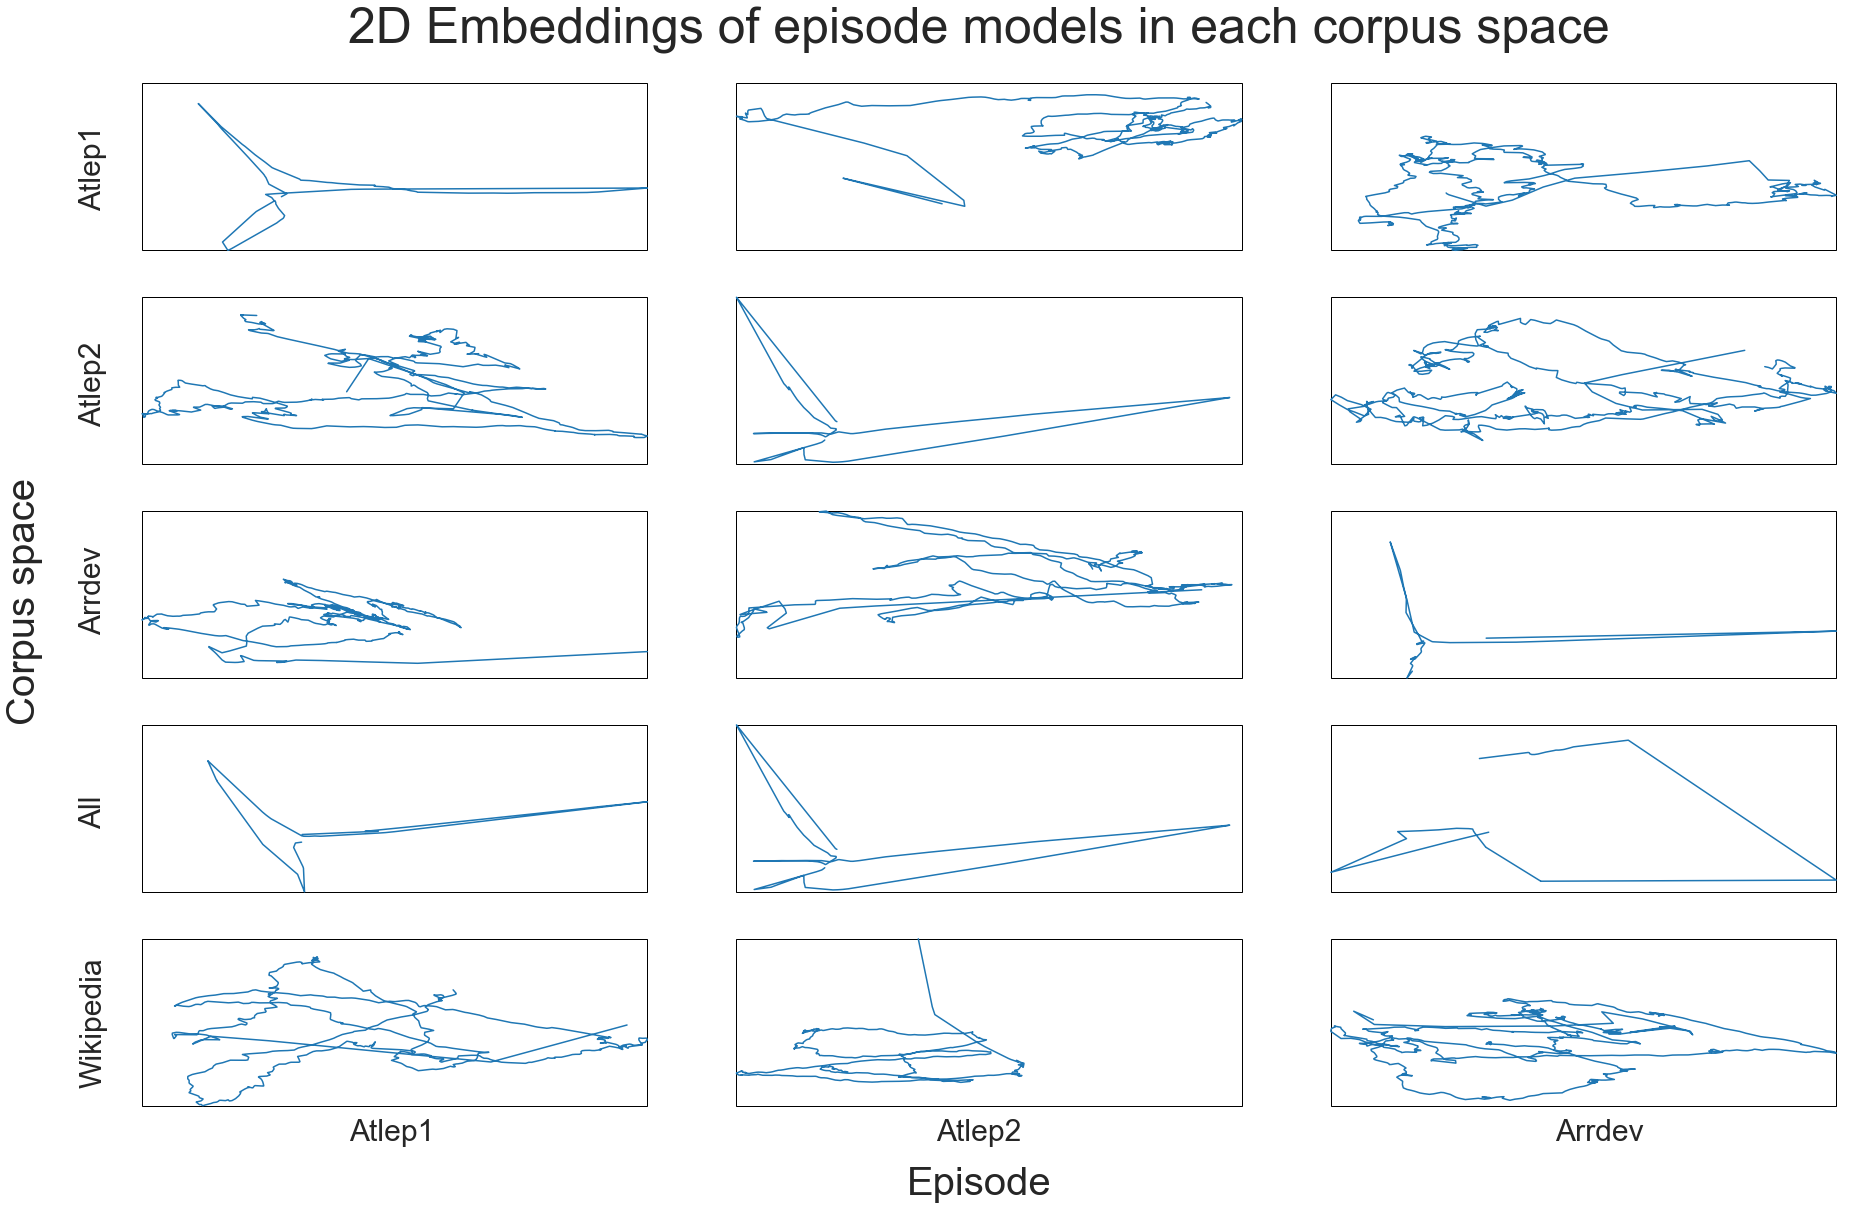

In [14]:
# working 2d plots
fig, ax = plt.subplots(5, 3)#, sharex=True, sharey=True)
fig.set_size_inches(25,15)

for (i,j), axis in np.ndenumerate(ax):

    hyp.plot(ep_inspace.iloc[i,j], ndims=2, ax=axis, show=False)
    

fig.text(0.5, -0.05, 'Episode', ha='center', fontsize=40)
fig.text(0.15, 0, 'Atlep1', fontsize=30)
fig.text(0.5, 0, 'Atlep2', ha='center', fontsize=30)
fig.text(0.82, 0, 'Arrdev', fontsize=30)

fig.text(-0.04, 0.5, 'Corpus space', va='center', rotation='vertical', fontsize=40)
fig.text(0, 0.92, 'Atlep1', rotation='vertical', fontsize=30)
fig.text(0, 0.72, 'Atlep2', rotation='vertical', fontsize=30)
fig.text(0, 0.53, 'Arrdev', rotation='vertical', fontsize=30)
fig.text(0, 0.3, 'All', rotation='vertical', fontsize=30)
fig.text(0, 0.15, 'Wikipedia', rotation='vertical', fontsize=30)

fig.suptitle('2D Embeddings of episode models in each corpus space', y=1.05, fontsize=50)

#fig.savefig('../../figures/ep-inspace-2d.pdf', bbox_inches='tight')
fig

In [15]:
# # not working 3D plot grid
# fig = plt.figure()
# for (i,j), model in np.ndenumerate(ep_inspace):
#     axis = fig.add_subplot(i+1, j+1, i+j+1, projection='3d')
#     hyp.plot(model, ax=axis, show=False)


atlep1 in atlep1 space:


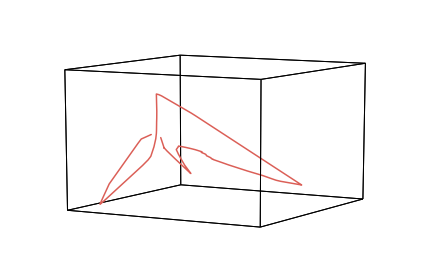

atlep1 in atlep2 space:


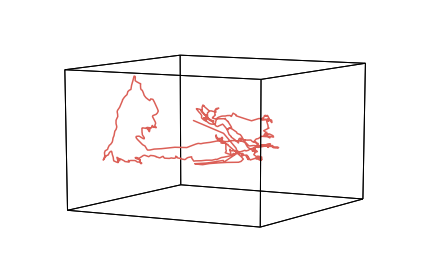

atlep1 in arrdev space:


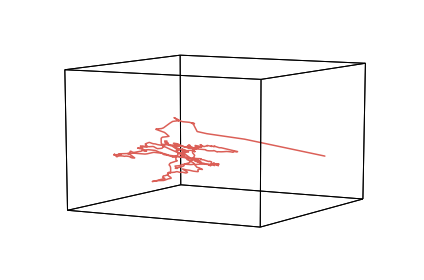

atlep1 in all space:


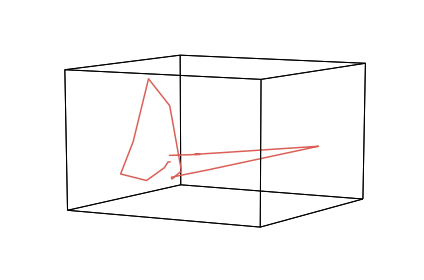

atlep1 in wikipedia space:


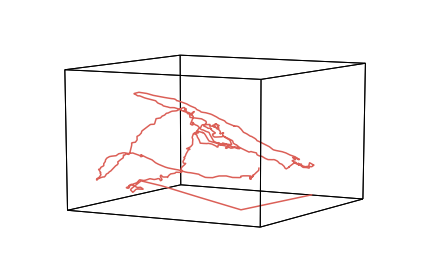

atlep2 in atlep1 space:


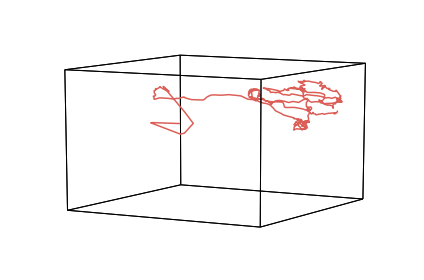

atlep2 in atlep2 space:


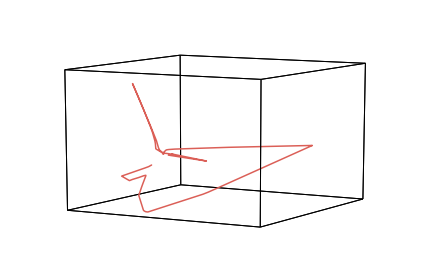

atlep2 in arrdev space:


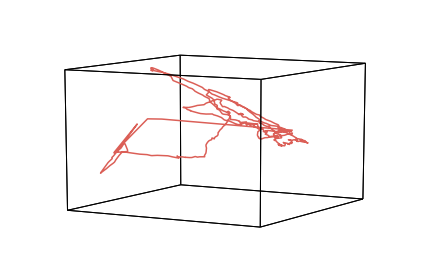

atlep2 in all space:


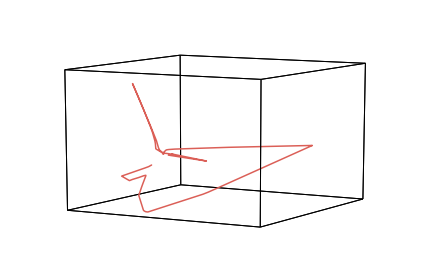

atlep2 in wikipedia space:


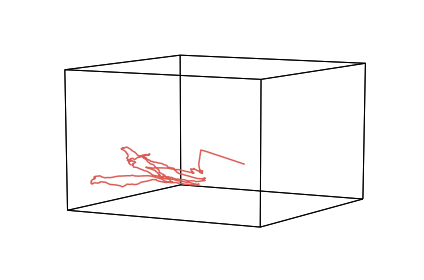

arrdev in atlep1 space:


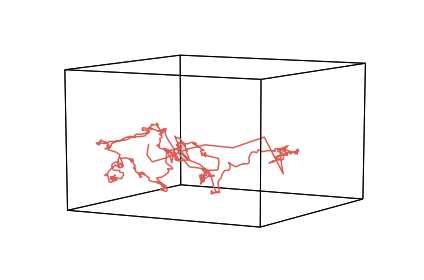

arrdev in atlep2 space:


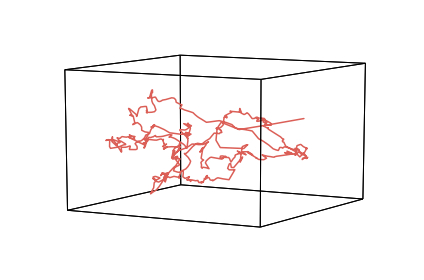

arrdev in arrdev space:


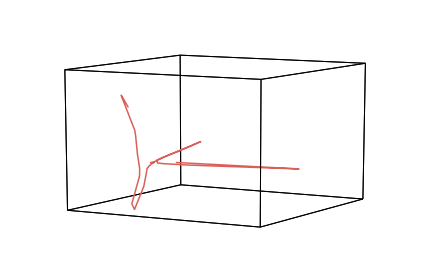

arrdev in all space:


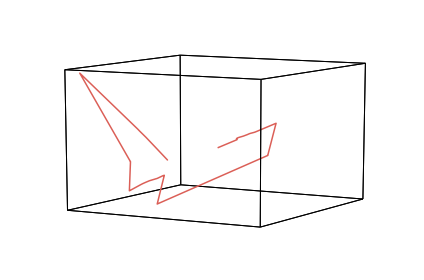

arrdev in wikipedia space:


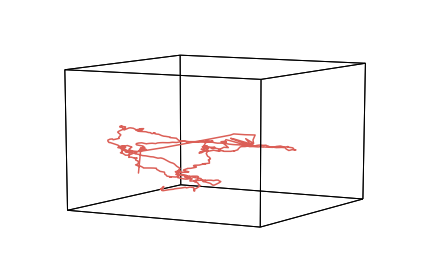

In [16]:
for col, data in ep_inspace.iteritems():
    for row, a in ep_inspace.iterrows():
        print(col + ' in ' + row + ' space:')
        hyp.plot(ep_inspace.loc[row,col])

## hyperalign episode models across spaces

In [16]:
ep_inspace_aligned = pd.DataFrame(columns=ep_inspace.columns, index=ep_inspace.index)

for col in ep_inspace_aligned.columns:
    ep_inspace_aligned[col] = hyp.align(ep_inspace[col].tolist())

atlep1 in atlep1 space:


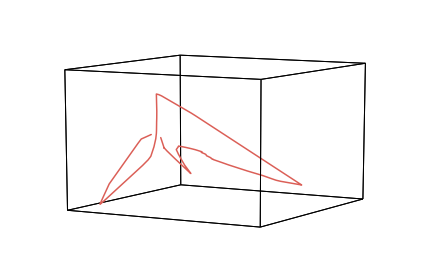

atlep1 in atlep2 space:


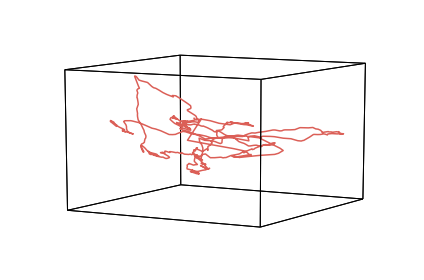

atlep1 in arrdev space:


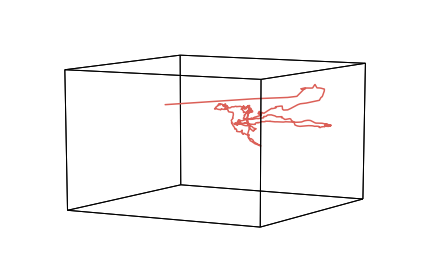

atlep1 in all space:


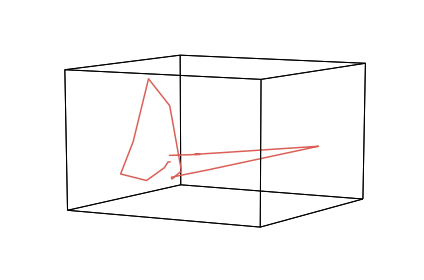

atlep1 in wikipedia space:


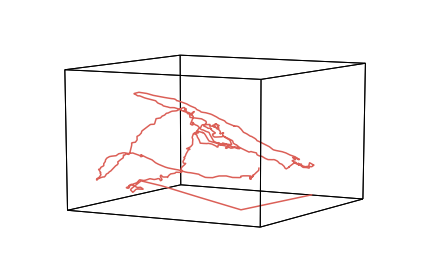

atlep2 in atlep1 space:


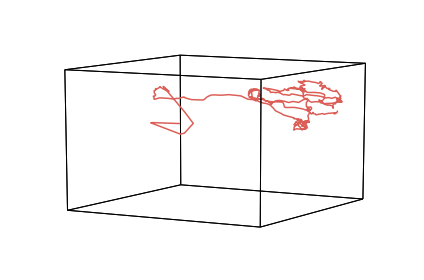

atlep2 in atlep2 space:


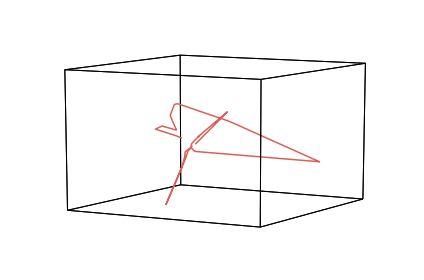

atlep2 in arrdev space:


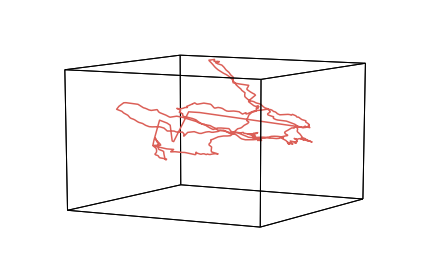

atlep2 in all space:


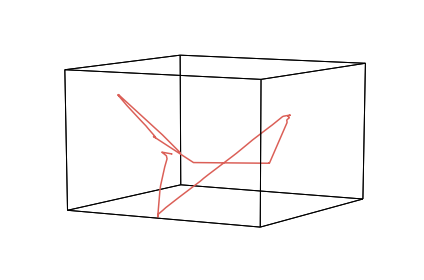

atlep2 in wikipedia space:


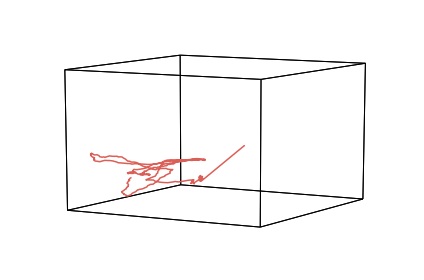

arrdev in atlep1 space:


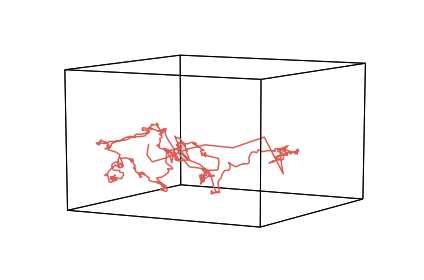

arrdev in atlep2 space:


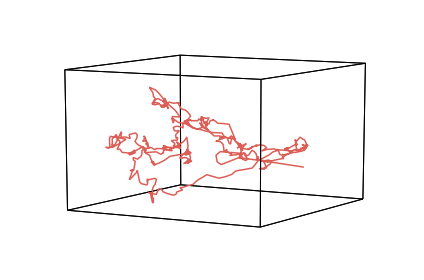

arrdev in arrdev space:


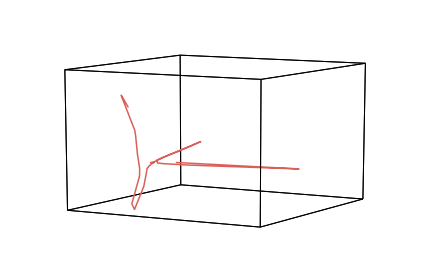

arrdev in all space:


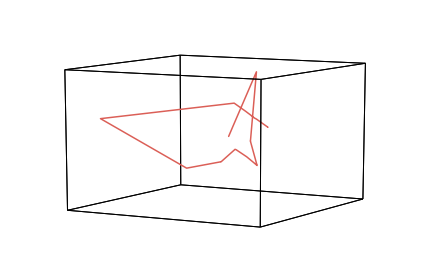

arrdev in wikipedia space:


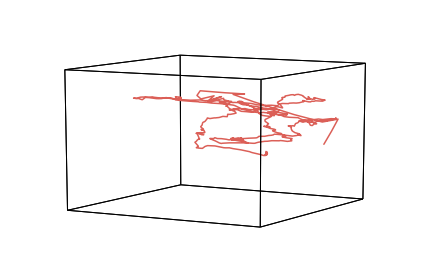

In [18]:
for col, data in ep_inspace_aligned.iteritems():
    for row, a in ep_inspace_aligned.iterrows():
        print(col + ' in ' + row + ' space:')
        hyp.plot(ep_inspace_aligned.loc[row,col])

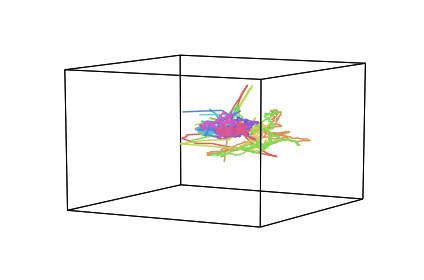

In [18]:
hyp.plot(ep_inspace_aligned.unstack().values.tolist(), animate=False, frame_rate=200, zoom=3)

In [19]:
for col in ep_inspace_aligned.columns:
    for row in ep_inspace_aligned.index:
        if col != row:
            print('\nEpisode: ' + col + ', Corpus: ' + row)
            msd = np.mean(np.diag(cdist(ep_inspace_aligned.loc[row,col], ep_inspace_aligned.loc[col,col], 
                                        'sqeuclidean')))
            print('\tMSD = ' + str(msd))


Episode: atlep1, Corpus: atlep2
	MSD = 0.039131846053068936

Episode: atlep1, Corpus: arrdev
	MSD = 0.03925521874508142

Episode: atlep1, Corpus: all
	MSD = 0.009987827704447842

Episode: atlep1, Corpus: wikipedia
	MSD = 0.033850641488736115

Episode: atlep2, Corpus: atlep1
	MSD = 0.013021499232790907

Episode: atlep2, Corpus: arrdev
	MSD = 0.010880193057297493

Episode: atlep2, Corpus: all
	MSD = 0.004288292016924132

Episode: atlep2, Corpus: wikipedia
	MSD = 0.009621941993870495

Episode: arrdev, Corpus: atlep1
	MSD = 0.011650723909622065

Episode: arrdev, Corpus: atlep2
	MSD = 0.011192350362010734

Episode: arrdev, Corpus: all
	MSD = 0.004465441052055453

Episode: arrdev, Corpus: wikipedia
	MSD = 0.011177180421845229
